In [2]:
from datasets import load_dataset
import polars as pl
import matplotlib.pyplot as plt

ds = load_dataset("jziebura/polish_youth_slang_classification")

df_train = ds["train"].to_polars()
df_test = ds["test"].to_polars()
df_val = ds["validation"].to_polars()

sentyment,count,percent
i8,u32,f64
1,2219,51.16
0,1259,29.03
2,859,19.81


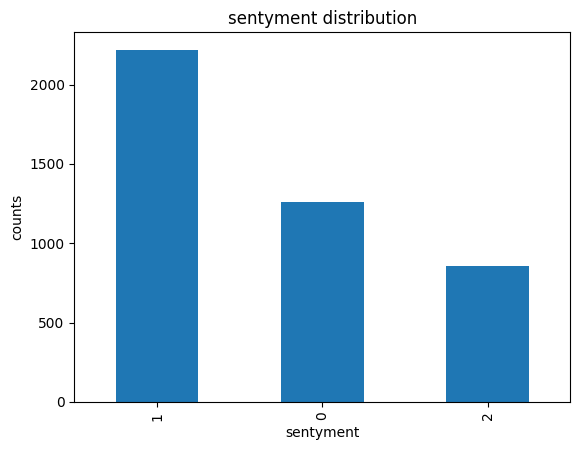

In [5]:
total = len(df_train)
counts = df_train["sentyment"].value_counts().sort("count", descending=True)
counts = counts.with_columns((pl.col("count") / total * 100).round(2).alias("percent"))

display(counts)

counts_pd = counts.to_pandas()
counts_pd.plot.bar(x="sentyment", y="count", legend=False)
plt.ylabel("counts")
plt.title("sentyment distribution")
plt.show()

In [ ]:
import polars as pl


def missing_stats(df, name):
    total = df.height
    missing = df.filter(
        pl.col("tekst").is_null() | (pl.col("tekst").str.replace_all(r"\s+", "") == "")
    ).height
    return {
        "split": name,
        "total": total,
        "missing": missing,
        "percent": round(missing / total * 100, 2),
    }


rows = [
    missing_stats(df_train, "train"),
    missing_stats(df_val, "validation"),
    missing_stats(df_test, "test"),
]

res = pl.DataFrame(rows)
res

split,total,missing,percent
str,i64,i64,f64
"""train""",4337,0,0.0
"""validation""",542,0,0.0
"""test""",543,0,0.0


In [17]:
for i, txt in enumerate(df_train["tekst"].head(6).to_list(), 1):
    print(f"{i}:\n{txt}\n")

1:
 - Masz może lejsy, Damian? - Mam, ale ci nie dam, Furto!                

2:
 - Siema mordo, skąd Gucio ma kase na te markowe ubrania? - Rzuca buchem od kilku tygodni.                

3:
 Gówniarz chędożony! Jak nie masz gdzie palcy wsadzić to sobie w dupie pogrzeb!                

4:
 - Zaraz wszystko z blatu w kuchni wyląduje w koszu jest taki jebnik tam !                

5:
  Baka! 

6:
Rano koniecznie jest z cytryną woda, bo wczoraj był lekki melanż

